In [20]:
from IPython.display import display, HTML

display(HTML("""
<div style="
    background: linear-gradient(135deg, #1a1a2e, #16213e, #0f3460);
    border-radius: 16px;
    padding: 40px;
    font-family: 'Segoe UI', sans-serif;
    text-align: center;
    border: 2px solid #e94560;
    box-shadow: 0 0 30px rgba(233, 69, 96, 0.3);
">
    <div style="color: #e94560; font-size: 13px; letter-spacing: 4px; text-transform: uppercase; margin-bottom: 10px;">
        ✦ Latihan Asistensi ADM ✦
    </div>
    <div style="color: #ffffff; font-size: 28px; font-weight: 700; margin-bottom: 8px;">
        Part 3: Predictive Analytics & Hypothesis Testing
    </div>
    <div style="color: #a8b2d8; font-size: 14px; margin-bottom: 24px;">
        PT Surya Ritel Nusantara — cleaned_surya2025.csv
    </div>
    <hr style="border: none; border-top: 1px solid #e94560; margin: 20px auto; width: 60%;">
    <div style="color: #ccd6f6; font-size: 18px; font-weight: 600;">Iman Satyo Adi</div>
    <div style="color: #a8b2d8; font-size: 14px; margin-top: 6px;">NPM: 2306208262</div>
    <a href="https://github.com/mnstyd" target="_blank" style="
        display: inline-block;
        margin-top: 16px;
        padding: 8px 20px;
        background: #e94560;
        color: white;
        border-radius: 20px;
        text-decoration: none;
        font-size: 13px;
        letter-spacing: 1px;
    ">https://github.com/mnstyd</a>
</div>
"""))

In [21]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

# model
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC # support vector classifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import preprocessing
from sklearn.multioutput import MultiOutputClassifier

# prep data
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split

# evaluasi
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# import data
from sklearn import datasets

# visualisasi Decision Tree model
import sklearn.tree as tree
import pydotplus
from six import StringIO
from IPython.display import Image

In [22]:
df = pd.read_csv("/content/cleaned_surya2025.csv")
df

,Transaction_Date,Store_Region,Product_Category,Sales_Revenue_IDR,Marketing_Spend_IDR,Operational_Cost_IDR,Staff_Turnover_Rate,Customer_Satisfaction_Score,Profit_Margin,CSAT_Status
0,2025-10-16,Jawa,Inverter,113953792,20000000,77000000,0.03,4.9,0.324288,Excellent
1,2025-07-12,Kalimantan,Solar Panel,36559139,6000000,43000000,0.13,3.0,-0.176176,Acceptable
2,2024-07-22,Sumatera,Auto-Cooling Fan,379980395,42000000,91000000,0.01,5.0,0.760514,Excellent
3,2025-12-15,Bali,Inverter,137004915,14000000,75000000,0.09,3.5,0.452574,Acceptable
4,2024-04-09,Bali,Inverter,53767983,7000000,137000000,0.24,2.0,-1.547985,Critical
...,...,...,...,...,...,...,...,...,...,...
1195,2024-09-26,Jawa,Inverter,186079244,31000000,86000000,0.22,1.9,0.537831,Critical
1196,2024-07-28,Jawa,Smart LED,325019173,36000000,38000000,0.15,3.3,0.883084,Acceptable
1197,2024-02-06,Jawa,Auto-Cooling Fan,405816506,43000000,40000000,0.12,3.2,0.901433,Acceptable
1198,2024-02-12,Jawa,Auto-Cooling Fan,305312339,37000000,77000000,0.11,3.5,0.747799,Acceptable


In [23]:
# mengecek dtype 2 data ini karena di excel agak kurang convincing
# make sure dua-duanya float64 sebelum melanjutkan

print(df[['Staff_Turnover_Rate', 'Customer_Satisfaction_Score']].dtypes)
print(df[['Staff_Turnover_Rate', 'Customer_Satisfaction_Score']].head())

Staff_Turnover_Rate            float64
Customer_Satisfaction_Score    float64
dtype: object
   Staff_Turnover_Rate  Customer_Satisfaction_Score
0                 0.03                          4.9
1                 0.13                          3.0
2                 0.01                          5.0
3                 0.09                          3.5
4                 0.24                          2.0


In [24]:
# mengganti Transaction_Date ke DatetimeIndex dari Int untuk resample
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
df = df.set_index('Transaction_Date')

df_monthly_sales = df['Sales_Revenue_IDR'].resample('ME').sum().to_frame()
print(df_monthly_sales.head())
print(df_monthly_sales.info())

                  Sales_Revenue_IDR
Transaction_Date                   
2024-01-31              10084604590
2024-02-29               7595318596
2024-03-31              11561590412
2024-04-30              11282881278
2024-05-31              13465389488
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 2024-01-31 to 2025-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Sales_Revenue_IDR  24 non-null     int64
dtypes: int64(1)
memory usage: 384.0 bytes
None


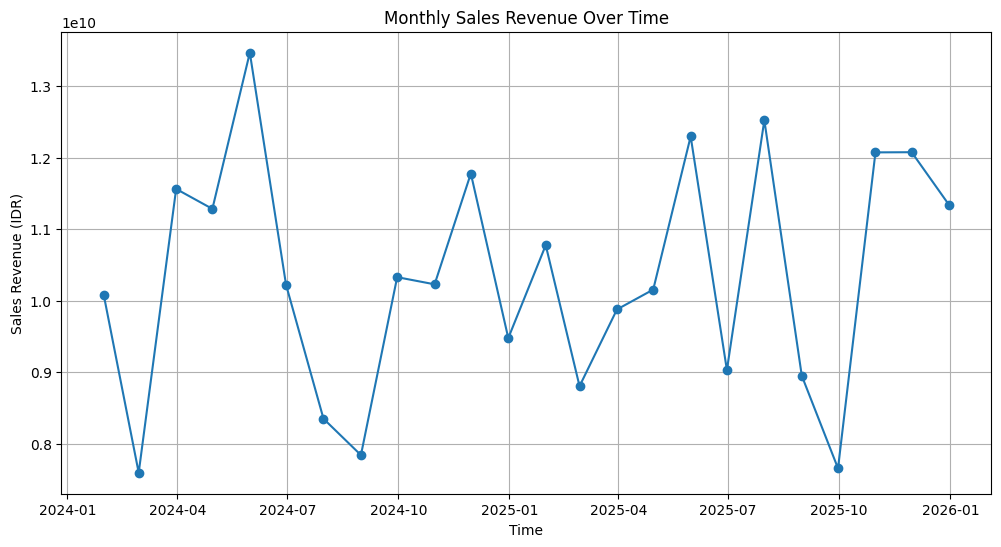

In [25]:
# analisis data untuk seasonality dan trend (untuk pattern)
# untuk mendetermine pilihan metode moving average

plt.figure(figsize=(12, 6))
plt.plot(df_monthly_sales.index, df_monthly_sales['Sales_Revenue_IDR'], marker='o', linestyle='-')
plt.title('Monthly Sales Revenue Over Time')
plt.xlabel('Time')
plt.ylabel('Sales Revenue (IDR)')
plt.grid(True)
plt.show()

In [26]:
# untuk melakukan analsis seasonality dan trend, dilakukan seasonal decomposition pada df_monthly_sales
# akan memisah time series menjadi trend, seasonal, dan residual components

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df_monthly_sales['Sales_Revenue_IDR'], model='additive', period=12)

Seasonal decomposition performed successfully.


<Figure size 1000x800 with 0 Axes>

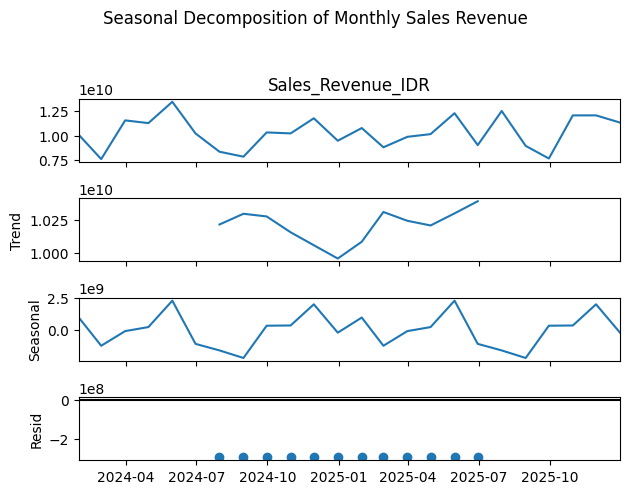

In [27]:
plt.figure(figsize=(10, 8))
result.plot()
plt.suptitle('Seasonal Decomposition of Monthly Sales Revenue', y=1.02) # adjust suptitle to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.98]) # adjust layout for suptitle
plt.show()

In [32]:
# yang saya pilih adalah: ARIMA
# kenapa ARIMA? karena data menunjukkan trend yang jelas pada hasil decomposition
# walaupun ada pola seasonal, ARIMA tetap memadai untuk forecasting 3 bulan (short term) sebagai dasar keputusan manajerial
# sebetulnya kalo seasonal forecasting lebih cocok SARIMA tapi tidak ada di pilihan

from statsmodels.tsa.arima.model import ARIMA

# membuat model ARIMA
# p=5 bp = 5 untuk menangkap pengaruh hingga 5 bulan sebelumnya (ada risiko overfitting karena data sedikit (24), tapi masih acceptable untuk forecast jangka pendek)
# d=1 karena data tidak stationary (ada trend), sehingga perlu differencing 1x
# q=0 karena model awal hanya mengandalkan komponen autoregressive
model = ARIMA(df_monthly_sales['Sales_Revenue_IDR'], order=(5,1,0))

model_fit = model.fit()

In [29]:
# prediction 3 bulan kedepan menggunakan get_forecast()

forecast_steps = 3
forecast_result = model_fit.get_forecast(steps=forecast_steps)

forecast_mean = forecast_result.predicted_mean

print("Forecasted Sales Revenue for the next three months:")
print(forecast_mean)


Forecasted Sales Revenue for the next three months:
2026-01-31    1.245612e+10
2026-02-28    1.151758e+10
2026-03-31    1.043853e+10
Freq: ME, Name: predicted_mean, dtype: float64


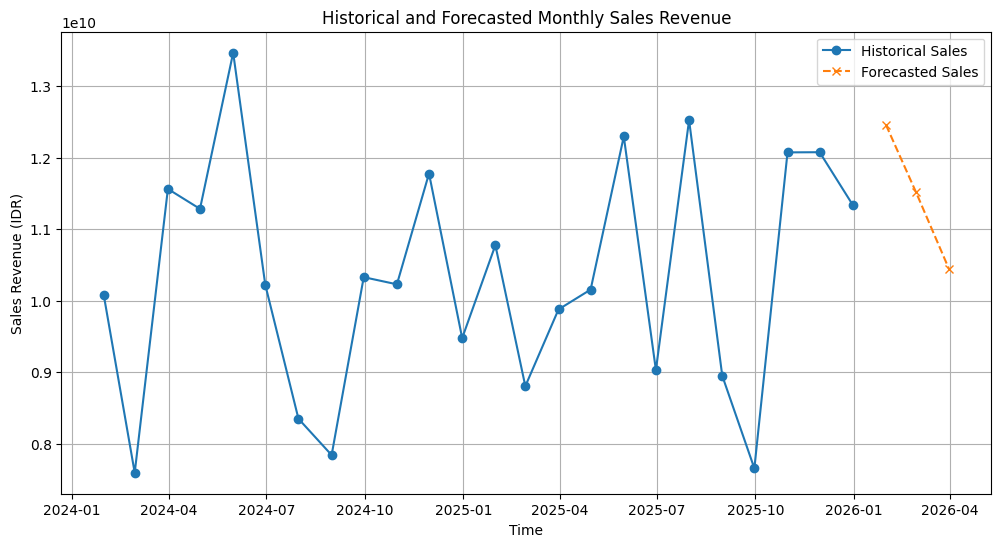

In [30]:
# visualisasi historical dan forecasted monthly sales revenue

plt.figure(figsize=(12, 6))
plt.plot(df_monthly_sales.index, df_monthly_sales['Sales_Revenue_IDR'], label='Historical Sales', marker='o')
plt.plot(forecast_mean.index, forecast_mean, label='Forecasted Sales', marker='x', linestyle='--')
plt.title('Historical and Forecasted Monthly Sales Revenue')
plt.xlabel('Time')
plt.ylabel('Sales Revenue (IDR)')
plt.legend()
plt.grid(True)
plt.show()

H₀ : Marketing Spend tidak memiliki korelasi terhadap Sales Revenue

H₁ : Marketing Spend memiliki korelasi positif terhadap Sales Revenue

In [34]:
# H₀: Marketing Spend tidak memiliki korelasi terhadap Sales Revenue
# H₁: Marketing Spend memiliki korelasi positif terhadap Sales Revenue
# p value: 0.02

from scipy import stats

corr, p_value = stats.pearsonr(df['Marketing_Spend_IDR'], df['Sales_Revenue_IDR'])
print(f"Correlation coefficient (r): {corr:.4f}")
print(f"P-value: {p_value:.4f}")

Correlation coefficient (r): 0.8438
P-value: 0.0000


**Kesimpulan Statistik:**

Dengan alpha = 0.05 (standar), p-value 0.02 < 0.05 sehingga H₀ ditolak. Terdapat korelasi positif yang signifikan secara # statistik antara Marketing Spend dan Sales Revenue.

**Kesimpulan Bisnis:**

Tim Marketing terbukti benar penambahan anggaran iklan berkorelasi positif dengan peningkatan pendapatan penjualan. Manajemen dapat mempertimbangkan untuk menambah Marketing Spend, terutama di region dengan performa tinggi, sebagai strategi pertumbuhan revenue jangka pendek.